In [1]:
import wfdb
from wfdb import processing
import pandas as pd
import numpy as np
from pathlib import Path
import copy
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

data_dir = Path.cwd().parent.parent / "apnea-ecg" / "1.0.0"

In [2]:
if torch.cuda.is_available():
    device = "cuda" 
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name())
else:
    device = "cpu"
    
device

CUDA version: 12.1
GPU: NVIDIA GeForce RTX 3070


'cuda'

In [3]:
record_path = Path(data_dir / 'a01r')
record = wfdb.rdrecord(record_path)
df = pd.DataFrame(record.p_signal, columns=record.sig_name)
print(df.head())

   Resp C  Resp A   Resp N  SpO2
0 -0.1015 -0.3446  0.23545  98.0
1 -0.1025 -0.3455  0.23640  98.0
2 -0.1035 -0.3464  0.23735  98.0
3 -0.1045 -0.3473  0.23830  98.0
4 -0.1055 -0.3482  0.23925  98.0


In [4]:
# Load the exact heartbeat timestamps (from the 'a01.qrs' file)
annotation = wfdb.rdann(str(data_dir / 'a01'), 'qrs')

# Ignore any heartbeats that were recorded after the SpO2 sensor was turned off
valid_beats = [idx for idx in annotation.sample if idx < len(df)]

# Compute the continuous Heart Rate (BPM)
# The data is sampled at 100 Hz. This calculates the time between beats and creates a BPM value for every single row in your DataFrame.
hr_array = processing.compute_hr(sig_len=len(df), qrs_inds=valid_beats, fs=100)

df['HR'] = hr_array
df['HR'] = df['HR'].interpolate().bfill()
df = df.iloc[:2940000]
print(df[['SpO2', 'HR']].head(10))

   SpO2         HR
0  98.0  67.415733
1  98.0  67.415733
2  98.0  67.415733
3  98.0  67.415733
4  98.0  67.415733
5  98.0  67.415733
6  98.0  67.415733
7  98.0  67.415733
8  98.0  67.415733
9  98.0  67.415733


In [5]:
time_in_minutes = df.index / (100 * 60)
time_in_minutes

Index([                   0.0, 0.00016666666666666666,  0.0003333333333333333,
                       0.0005,  0.0006666666666666666,  0.0008333333333333334,
                        0.001,  0.0011666666666666668,  0.0013333333333333333,
                       0.0015,
       ...
           489.99833333333333,               489.9985,      489.9986666666667,
            489.9988333333333,                489.999,     489.99916666666667,
            489.9993333333333,               489.9995,     489.99966666666666,
           489.99983333333336],
      dtype='float64', length=2940000)

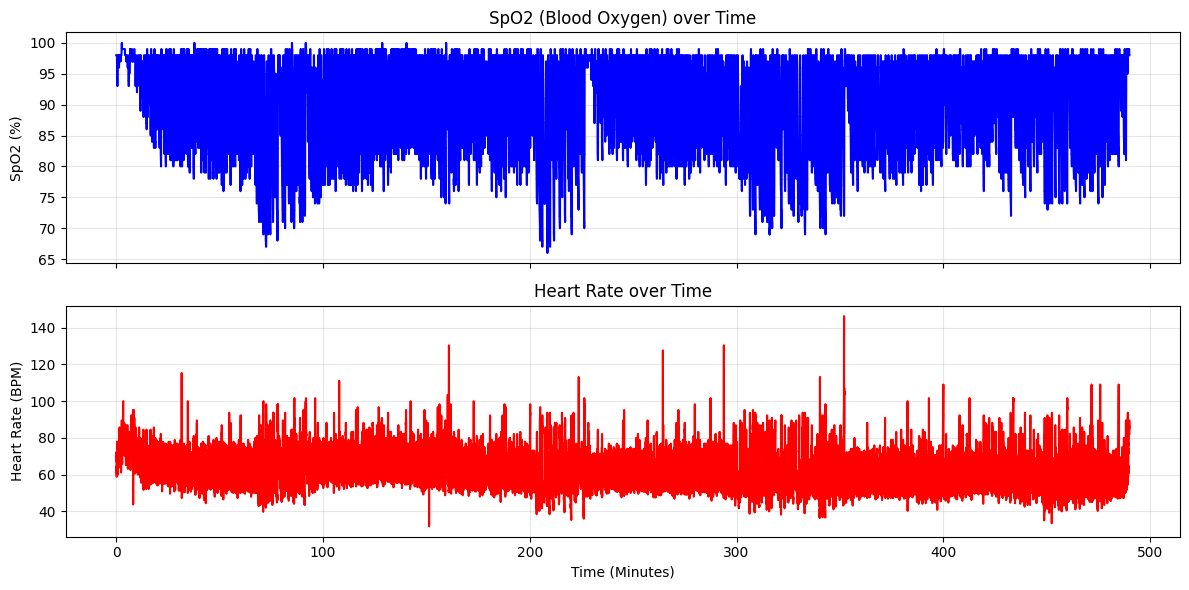

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Convert the X-axis from "data rows" into "Minutes"
# Our data is 100 rows per second. 
# So, 100 rows * 60 seconds = 6000 rows per minute.
time_in_minutes = df.index / (100 * 60)

# SpO2
ax1.plot(time_in_minutes, df['SpO2'], color='blue', linewidth=1.5)
ax1.set_title('SpO2 (Blood Oxygen) over Time')
ax1.set_ylabel('SpO2 (%)')
ax1.grid(True, alpha=0.3)

# Heart Rate
ax2.plot(time_in_minutes, df['HR'], color='red', linewidth=1.5)
ax2.set_title('Heart Rate over Time')
ax2.set_ylabel('Heart Rate (BPM)')
ax2.set_xlabel('Time (Minutes)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
train_patients = ['a01', 'a02', 'a03', 'b01', 'c01', 'c02']
test_patients = ['a04', 'c03']

def generate_dataset(patient_ids):
    patients_data = []

    for pid in patient_ids:
        print(f"Processing patient {pid}...")
        
        # Load SpO2 data
        record_r = wfdb.rdrecord(str(data_dir / f'{pid}r'))
        df = pd.DataFrame(record_r.p_signal, columns=record_r.sig_name)
        
        # Load heartbeat timestamps
        annotation = wfdb.rdann(str(data_dir / pid), 'qrs')
        valid_beats = [idx for idx in annotation.sample if idx < len(df)]
        
        # Compute the continuous Heart Rate (BPM)
        hr_array = processing.compute_hr(sig_len=len(df), qrs_inds=valid_beats, fs=100)
        df['HR'] = hr_array
        
        # Clean the data
        df['HR'] = df['HR'].interpolate().bfill().ffill()
                
        df = df[['SpO2', 'HR']].copy()
        df['Patient_ID'] = pid 
        patients_data.append(df)
        
    return patients_data

train_patients_data = generate_dataset(train_patients)
train_df = pd.concat(train_patients_data, ignore_index=True)
test_patients_data = generate_dataset(test_patients)
test_df = pd.concat(test_patients_data, ignore_index=True)

print("\n--- DATASET COMPLETE ---")
print(f"Total data rows (100 rows/sec): {len(train_df):,}")
print(train_df.head())

Processing patient a01...
Processing patient a02...
Processing patient a03...
Processing patient b01...
Processing patient c01...
Processing patient c02...
Processing patient a04...
Processing patient c03...

--- DATASET COMPLETE ---
Total data rows (100 rows/sec): 18,095,776
   SpO2         HR Patient_ID
0  98.0  67.415733        a01
1  98.0  67.415733        a01
2  98.0  67.415733        a01
3  98.0  67.415733        a01
4  98.0  67.415733        a01


In [8]:
"""
Downsampling 100Hz to 1Hz
"""

def train_test_split(patient_ids, df):
    X_list = []
    y_list = []
    
    for pid in patient_ids:
        patient_data = df[df['Patient_ID'] == pid].reset_index(drop=True)
        
        # Load the human doctor's labels from the .apn file
        # This gives us a list of letters like ['N', 'N', 'A', 'N'...] (N=Normal, A=Apnea)
        annotations = wfdb.rdann(str(data_dir / pid), 'apn')
        labels = annotations.symbol 
        
        # Loop through every minute of the doctor's labels
        for minute_idx, label in enumerate(labels):
            # 1 minute = 6000 rows (at 100 Hz)
            start_row = minute_idx * 6000
            end_row = start_row + 6000
            
            # Grab that exact 1-minute window from our DataFrame
            window = patient_data.iloc[start_row:end_row]
            
            # If the window is cut short (e.g., sensor fell off and we deleted those rows earlier), remove the window
            if len(window) != 6000 or (window['SpO2'] <= 50).any():
                continue
                
            # DOWNSAMPLING
            # Squash the 6000 rows into 60 rows (1 sample per second) by taking the mean of every 100 rows.
            spo2_sec = window['SpO2'].values.reshape(60, 100).mean(axis=1)
            hr_sec = window['HR'].values.reshape(60, 100).mean(axis=1)
            
            # Stack them side-by-side into a 60x2 matrix
            window_matrix = np.column_stack((spo2_sec, hr_sec))
            
            # Convert the text label into binary for PyTorch (1 = Apnea, 0 = Normal)
            binary_label = 1 if label == 'A' else 0
            
            X_list.append(window_matrix)
            y_list.append(binary_label)

    # Convert the standard Python lists into heavy-duty NumPy arrays
    X = np.array(X_list)
    y = np.array(y_list)

    print("\n--- WINDOWING COMPLETE ---")
    print(f"Data Shape (X):  {X.shape} -> (Total Windows, Time Steps, Features)")
    print(f"Label Shape (Y): {y.shape} -> (Total Windows)")
    print(f"Apnea Events:    {sum(y)}")
    print(f"Normal Events:   {len(y) - sum(y)}")

    return X, y

X_train, y_train = train_test_split(train_patients, train_df)
X_test, y_test = train_test_split(test_patients, test_df)


--- WINDOWING COMPLETE ---
Data Shape (X):  (2946, 60, 2) -> (Total Windows, Time Steps, Features)
Label Shape (Y): (2946,) -> (Total Windows)
Apnea Events:    1154
Normal Events:   1792

--- WINDOWING COMPLETE ---
Data Shape (X):  (803, 60, 2) -> (Total Windows, Time Steps, Features)
Label Shape (Y): (803,) -> (Total Windows)
Apnea Events:    314
Normal Events:   489


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

original_shape = X_train.shape
num_features = original_shape[-1]

# Sklearn scaler requires 2D shape
# Flatten to 2D (samples * timesteps, features)
X_train_reshaped = X_train.reshape(-1, num_features)

X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(original_shape)

test_shape = X_test.shape
X_test_reshaped = X_test.reshape(-1, num_features)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(test_shape) # transform instead of fit_transform, as we use the mean/variance of training dataset so no data leakage

In [10]:
class SleepApneaDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.tensor(X_data, dtype=torch.float32) # (3865, 60, 2)
        self.y = torch.tensor(y_data, dtype=torch.float32).unsqueeze(1) # (3865,) ==> (3865, 1) as model outputs a prediction shape of (32, 1) and need shape match for evaluation

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SleepApneaDataset(X_train_scaled, y_train)
test_dataset = SleepApneaDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training Windows: {len(train_dataset)}")
print(f"Testing Windows:  {len(test_dataset)}")
print(f"Batches per Epoch: {len(train_loader)}")

Training Windows: 2946
Testing Windows:  803
Batches per Epoch: 93


In [11]:
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    """Injects 'time stamps' into the data so the Transformer knows the order of seconds."""
    def __init__(self, d_model, max_len=60):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)

        # Sinusoidal Positional Encoding
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe) # set it as a non-trainable tensor

    def forward(self, x):
        # x shape: (Batch, Time, Features)
        x = x + self.pe[:, :x.size(1), :]
        return x

class ApneaTransformer(nn.Module):
    def __init__(self, num_features=2, d_model=32, num_heads=4, num_layers=2):
        super().__init__()
        self.input_projection = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=60)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=num_heads, 
            dim_feedforward=64, # Keeps the model small for Edge AI
            dropout=0.1, 
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Linear(16, 1) # Outputs a single raw score
        )

    def forward(self, x):
        # Input 'x' is a batch of our 60x2 matrices. Shape (32, 60, 2)
        x = self.input_projection(x)  # Shape (32, 60, 32)
        x = self.pos_encoder(x)    
        x = self.transformer_encoder(x) # Shape (32, 60, 32)
        x = x.mean(dim=1) # Shape (32, 32)
        output = self.classifier(x) # Shape (32, 1)
        return output

In [12]:
from torchinfo import summary

model = ApneaTransformer().to(device)

summary(model)

Layer (type:depth-idx)                                            Param #
ApneaTransformer                                                  --
├─Linear: 1-1                                                     96
├─PositionalEncoding: 1-2                                         --
├─TransformerEncoder: 1-3                                         --
│    └─ModuleList: 2-1                                            --
│    │    └─TransformerEncoderLayer: 3-1                          8,544
│    │    └─TransformerEncoderLayer: 3-2                          8,544
├─Sequential: 1-4                                                 --
│    └─Linear: 2-2                                                528
│    └─ReLU: 2-3                                                  --
│    └─Linear: 2-4                                                17
Total params: 17,729
Trainable params: 17,729
Non-trainable params: 0

In [13]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               scaler: torch.amp.GradScaler,
               device=device) -> tuple[float, float]:
    
    model.train()
    train_loss, total_correct, total_samples = 0, 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device) 

        optimizer.zero_grad()

        if scaler is not None and device == "cuda":
            with torch.amp.autocast(device):
                y_pred = model(X)
                loss = loss_fn(y_pred, y)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()  
        else:
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()
        
        train_loss += loss.item()

        y_pred_class = (y_pred > 0.0).float() 
        total_correct += (y_pred_class == y).sum().item()
        total_samples += len(y)
        
    return train_loss / len(dataloader), total_correct / total_samples

def eval_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device=device) -> tuple[float, float]:
    
    model.eval()
    test_loss, total_correct, total_samples = 0, 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred = model(X)
            loss = loss_fn(test_pred, y)
            test_loss += loss.item()

            test_pred_labels = (test_pred > 0.0).float()
            total_correct += (test_pred_labels == y).sum().item()
            total_samples += len(y)

    return test_loss / len(dataloader), total_correct / total_samples

def run_experiment(model: torch.nn.Module,
                   model_save_name: str,
                   train_dataloader: torch.utils.data.DataLoader,
                   val_dataloader: torch.utils.data.DataLoader,
                   loss_fn: torch.nn.Module,
                   optimizer: torch.optim.Optimizer,
                   scaler: torch.amp.GradScaler,
                   epochs: int,
                   device=device):
    
    results = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    best_val_acc = 0.0
    best_model_weights = None
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=epochs,      
        eta_min=1e-6         
    )
    
    print(f"Starting Training: {model_save_name}")

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device,
                                           scaler=scaler)
        
        val_loss, val_acc = eval_step(model=model,
                                      dataloader=val_dataloader,
                                      loss_fn=loss_fn,
                                      device=device)
        
        scheduler.step()
        
        if val_acc > best_val_acc: 
            best_val_acc = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"Epoch {epoch} | New Best Val Acc: {val_acc:.4f} (Saved)")
            torch.save(model.state_dict(), f"{model_save_name}.pth")

        print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        print(f"\nLoaded best model weights with Val Acc: {best_val_acc:.4f}")

    return results

In [14]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

model = ApneaTransformer(num_features=2, d_model=32, num_heads=4, num_layers=2).to(device)

NUM_EPOCHS = 25 
model_save_name = "apnea_transformer_v1"

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(params=model.parameters(),
                              lr=0.001,
                              weight_decay=0.01)

scaler = torch.amp.GradScaler(device) if device == "cuda" else None

result = run_experiment(model=model,
                        model_save_name=model_save_name,
                        train_dataloader=train_loader, 
                        val_dataloader=test_loader,  
                        loss_fn=loss_fn,
                        optimizer=optimizer,
                        scaler=scaler,
                        epochs=NUM_EPOCHS,
                        device=device)

Starting Training: apnea_transformer_v1


  4%|▍         | 1/25 [00:00<00:23,  1.01it/s]

Epoch 0 | New Best Val Acc: 0.9527 (Saved)
Epoch: 0 | Train Loss: 0.2823 | Val Loss: 0.1485 | Val Acc: 0.9527


  8%|▊         | 2/25 [00:01<00:17,  1.35it/s]

Epoch 1 | New Best Val Acc: 0.9714 (Saved)
Epoch: 1 | Train Loss: 0.1351 | Val Loss: 0.0923 | Val Acc: 0.9714


...

Epoch: 22 | Train Loss: 0.0560 | Val Loss: 0.1468 | Val Acc: 0.9589


 96%|█████████▌| 24/25 [00:14<00:00,  1.70it/s]

Epoch: 23 | Train Loss: 0.0562 | Val Loss: 0.1494 | Val Acc: 0.9589


100%|██████████| 25/25 [00:14<00:00,  1.69it/s]

Epoch: 24 | Train Loss: 0.0554 | Val Loss: 0.1497 | Val Acc: 0.9589

Loaded best model weights with Val Acc: 0.9714


In [15]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_trues = []

with torch.inference_mode():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        logits = model(batch_X)
        
        # Convert logits to binary 0 or 1
        preds = (logits > 0.0).float().cpu().numpy()
        trues = batch_y.cpu().numpy()
        
        all_preds.extend(preds)
        all_trues.extend(trues)

all_preds = np.array(all_preds).flatten()
all_trues = np.array(all_trues).flatten()

print(classification_report(all_trues, all_preds, target_names=['Normal (0)', 'Apnea (1)']))

              precision    recall  f1-score   support

  Normal (0)       0.97      0.99      0.98       489
   Apnea (1)       0.98      0.95      0.96       314

    accuracy                           0.97       803
   macro avg       0.97      0.97      0.97       803
weighted avg       0.97      0.97      0.97       803



In [16]:
model.eval()
missed_apnea_indices = []

# Get all true Apnea indices
apnea_indices = np.where(y_test == 1)[0]

with torch.inference_mode():
    for idx in apnea_indices:
        # Grab the scaled data for THIS specific index in the loop
        X_scaled = X_test_scaled[idx] 
        
        # Prepare for AI
        tensor_X = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(0).to(device)
        
        # Get prediction
        logit = model(tensor_X)
        probability = torch.sigmoid(logit).item() * 100
        
        # If the AI predicts Normal (< 50%) for an actual Apnea event
        if probability < 50:
            missed_apnea_indices.append((idx, probability))

print(f"The AI missed {len(missed_apnea_indices)} Apnea events.")
print("Here are their original indices in X_test:")
for idx, prob in missed_apnea_indices:
    print(f"Index: {idx} | AI Predicted: {prob:.1f}% (Expected > 50%)")

The AI missed 17 Apnea events.
Here are their original indices in X_test:
Index: 34 | AI Predicted: 1.6% (Expected > 50%)
Index: 36 | AI Predicted: 5.8% (Expected > 50%)
Index: 37 | AI Predicted: 5.7% (Expected > 50%)
Index: 38 | AI Predicted: 14.5% (Expected > 50%)
Index: 40 | AI Predicted: 44.5% (Expected > 50%)
Index: 41 | AI Predicted: 11.6% (Expected > 50%)
Index: 42 | AI Predicted: 37.2% (Expected > 50%)
Index: 43 | AI Predicted: 29.2% (Expected > 50%)
Index: 45 | AI Predicted: 27.4% (Expected > 50%)
Index: 47 | AI Predicted: 29.7% (Expected > 50%)
Index: 49 | AI Predicted: 4.4% (Expected > 50%)
Index: 55 | AI Predicted: 22.3% (Expected > 50%)
Index: 133 | AI Predicted: 47.1% (Expected > 50%)
Index: 151 | AI Predicted: 37.6% (Expected > 50%)
Index: 156 | AI Predicted: 3.8% (Expected > 50%)
Index: 282 | AI Predicted: 1.4% (Expected > 50%)
Index: 283 | AI Predicted: 1.5% (Expected > 50%)


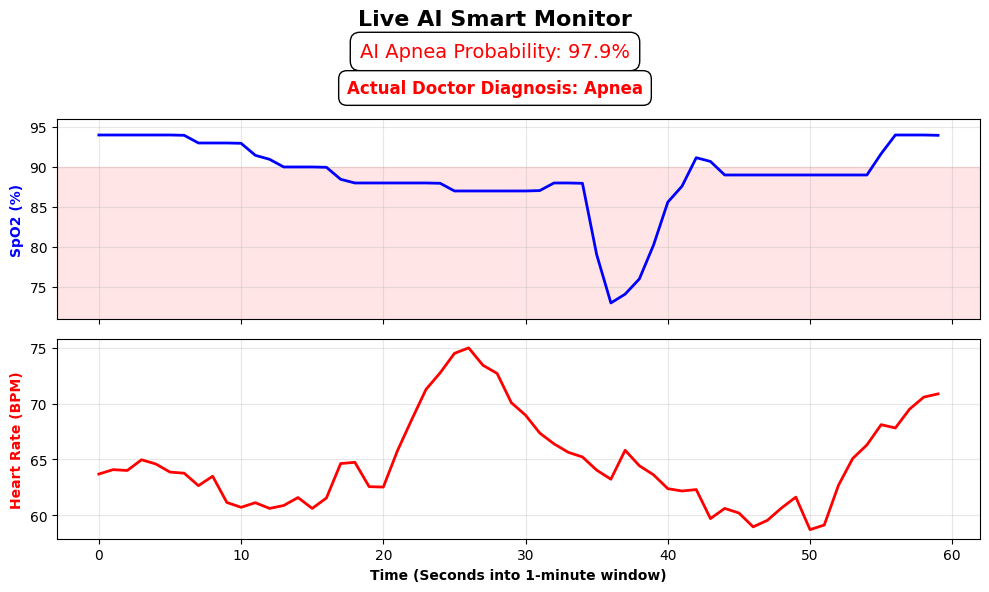

In [17]:
apnea_indices = np.where(y_test == 1)[0]
sample_idx = apnea_indices[23]
# sample_idx = 1

sample_X_raw = X_test[sample_idx]           # Shape: (60, 2) - unscaled values
sample_X_scaled = X_test_scaled[sample_idx] # Shape: (60, 2) - Scaled values for inference
true_label = y_test[sample_idx]

model.eval()
with torch.inference_mode():
    tensor_X = torch.tensor(sample_X_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    logit = model(tensor_X)
    probability = torch.sigmoid(logit).item() * 100

time_sec = np.arange(60)
spo2 = sample_X_raw[:, 0] 
hr = sample_X_raw[:, 1]   

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle(f"Live AI Smart Monitor", fontsize=16, fontweight='bold')
fig.text(0.5, 0.90, f"AI Apnea Probability: {probability:.1f}%", 
         ha='center', fontsize=14, 
         color='red' if probability > 50 else 'green', 
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

label_text = "Apnea" if true_label == 1 else "Normal"
label_color = 'red' if true_label == 1 else 'green'

fig.text(0.5, 0.84, f"Actual Doctor Diagnosis: {label_text}", 
         ha='center', fontsize=12, fontweight='bold',
         color=label_color, 
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))


ax1.plot(time_sec, spo2, color='blue', linewidth=2)
ax1.set_ylabel('SpO2 (%)', color='blue', fontweight='bold')
ax1.axhspan(0, 90, color='red', alpha=0.1) # Shaded danger zone below 90%
ax1.set_ylim(min(spo2)-2, max(spo2)+2)
ax1.grid(True, alpha=0.3)

ax2.plot(time_sec, hr, color='red', linewidth=2)
ax2.set_ylabel('Heart Rate (BPM)', color='red', fontweight='bold')
ax2.set_xlabel('Time (Seconds into 1-minute window)', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

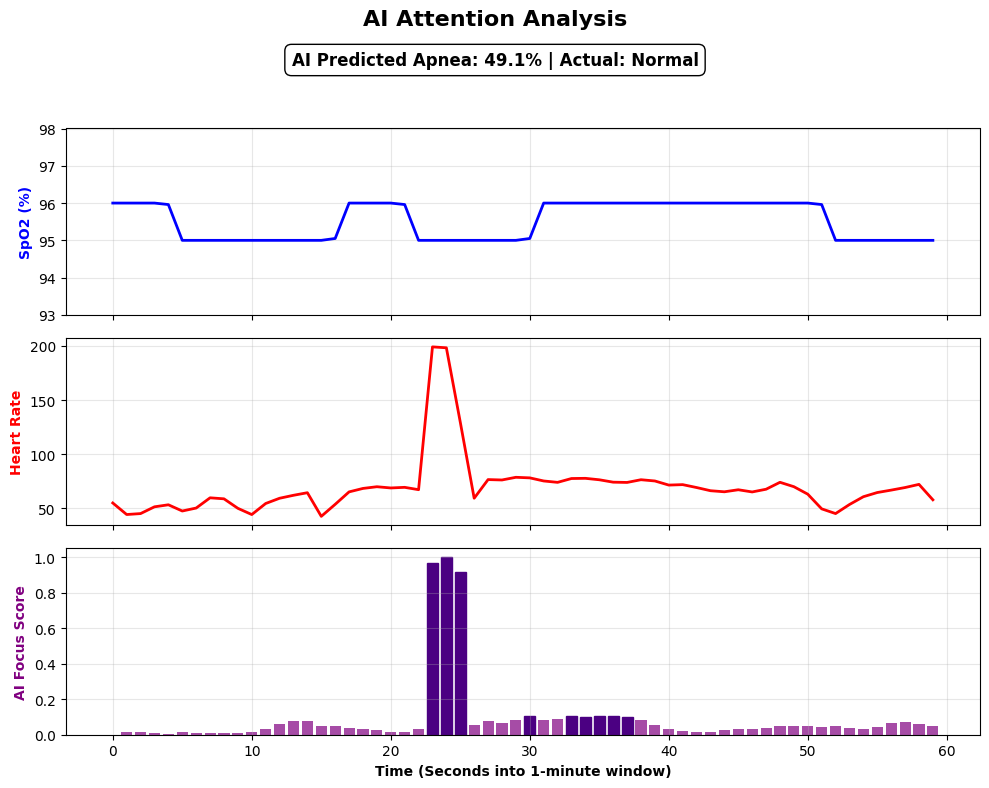

In [20]:
sample_idx = 383 
sample_X_raw = X_test[sample_idx]         
sample_X_scaled = X_test_scaled[sample_idx]
true_label = y_test[sample_idx]

model.eval()
with torch.inference_mode():
    tensor_X = torch.tensor(sample_X_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    
    logit = model(tensor_X)
    probability = torch.sigmoid(logit).item() * 100

    # Manually extract attention weights
    # Pass data through projection and positional encoding manually
    x = model.input_projection(tensor_X)
    x = model.pos_encoder(x)
    
    # Pass through all layers except last
    for layer in model.transformer_encoder.layers[:-1]:
        x = layer(x)
        
    last_layer = model.transformer_encoder.layers[-1]
    
    # We query the self-attention layer directly and set need_weights=True
    # attn_weights shape will be (1, 60, 60)
    _, attn_weights = last_layer.self_attn(x, x, x, need_weights=True)

time_sec = np.arange(60)
spo2 = sample_X_raw[:, 0]
hr = sample_X_raw[:, 1]

# The attention matrix is 60x60 (every second looking at every other second).
# Rows (Queries) and Columns (Keys)
# We care how much every other second in the minute pay attention to a second
importance_scores = attn_weights[0].mean(dim=0).cpu().numpy()

# Normalize
importance_scores = (importance_scores - importance_scores.min()) / (importance_scores.max() - importance_scores.min())

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle("AI Attention Analysis", fontsize=16, fontweight='bold')
label_text = "Apnea" if true_label == 1 else "Normal"
label_color = 'red' if true_label == 1 else 'green'
fig.text(0.5, 0.91, f"AI Predicted Apnea: {probability:.1f}% | Actual: {label_text}", 
         ha='center', fontsize=12, fontweight='bold',
         color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4'))
ax1.plot(time_sec, spo2, color='blue', linewidth=2)
ax1.set_ylabel('SpO2 (%)', color='blue', fontweight='bold')
ax1.axhspan(0, 90, color='red', alpha=0.1) 
ax1.set_ylim(min(spo2)-2, max(spo2)+2)
ax1.grid(True, alpha=0.3)
ax2.plot(time_sec, hr, color='red', linewidth=2)
ax2.set_ylabel('Heart Rate', color='red', fontweight='bold')
ax2.grid(True, alpha=0.3)
bars = ax3.bar(time_sec, importance_scores, color='purple', alpha=0.7)
ax3.set_ylabel('AI Focus Score', color='purple', fontweight='bold')
ax3.set_xlabel('Time (Seconds into 1-minute window)', fontweight='bold')
ax3.grid(True, alpha=0.3)

threshold = np.percentile(importance_scores, 85) # Top 15% most important seconds
for i, bar in enumerate(bars):
    if importance_scores[i] >= threshold:
        bar.set_color('indigo')
        bar.set_alpha(1.0)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

In [ ]:
HR_THRESHOLD = 20 
spiked_indices = []

# X_test shape is (Total Windows, 60 seconds, 2 features)
# Feature 0 = SpO2, Feature 1 = Heart Rate
for idx in range(len(X_test)):
    hr_sequence = X_test[idx][:, 1] # Grab only the HR column for this window
    
    # Calculate the difference between the highest and lowest HR in this minute
    hr_jump = np.max(hr_sequence) - np.min(hr_sequence)
    
    if hr_jump > HR_THRESHOLD:
        spiked_indices.append({
            "index": idx,
            "jump_magnitude": hr_jump,
            "max_hr": np.max(hr_sequence),
            "min_hr": np.min(hr_sequence)
        })

spiked_indices = sorted(spiked_indices, key=lambda x: x['jump_magnitude'], reverse=True)

print(f"Found {len(spiked_indices)} windows with a heart rate spike > {HR_THRESHOLD} BPM.")
print("-" * 50)
print(f"{'Index':<10} | {'HR Jump':<12} | {'Range (Min -> Max)'}")
print("-" * 50)

for item in spiked_indices[:20]: 
    print(f"{item['index']:<10} | {item['jump_magnitude']:>5.1f} BPM   | {item['min_hr']:>5.1f} -> {item['max_hr']:>5.1f}")

Found 453 windows with a heart rate spike > 20 BPM.
--------------------------------------------------
Index      | HR Jump      | Range (Min -> Max)
--------------------------------------------------
383        | 156.5 BPM   |  42.7 -> 199.2
65         | 154.5 BPM   |  53.9 -> 208.4
12         | 139.9 BPM   |  80.3 -> 220.1
13         | 137.2 BPM   |  71.4 -> 208.6
262        | 127.0 BPM   |  54.1 -> 181.1
435        | 119.9 BPM   |  41.3 -> 161.2
188        | 114.2 BPM   |  49.8 -> 164.1
159        | 109.9 BPM   |  64.5 -> 174.4
96         | 104.6 BPM   |  55.9 -> 160.5
488        | 104.2 BPM   |  39.4 -> 143.7
637        |  98.1 BPM   |  42.0 -> 140.1
70         |  96.6 BPM   |  57.0 -> 153.6
638        |  96.6 BPM   |  42.8 -> 139.4
26         |  91.6 BPM   |  69.2 -> 160.8
48         |  91.1 BPM   |  61.1 -> 152.2
2          |  89.0 BPM   |  77.3 -> 166.3
46         |  78.7 BPM   |  60.4 -> 139.0
36         |  78.0 BPM   |  59.6 -> 137.7
255        |  77.1 BPM   |  50.2 -> 127.3
4